In [17]:
import polars as pl
import pandas as pd
import numpy as np
from plotnine import *

## Resumen del Capítulo: Diseños Experimentales Alternativos al A/B Testing

En este capítulo se aborda cómo diseñar experimentos cuando el A/B testing tradicional no es viable, especialmente en contextos donde no es posible aleatorizar individuos (por ejemplo, clientes potenciales en marketing).

### 1. Del uso de datos panel al diseño experimental

En la Parte IV se trabajó con **datos panel** para estimar efectos causales a partir de observaciones repetidas en el tiempo. Sin embargo, ahora el enfoque cambia: en lugar de asumir que los datos ya existen, el objetivo es **diseñar un experimento que genere esos datos** de forma adecuada.

### 2. Geo-experimentos

Ante la dificultad de medir la incrementalidad del marketing (ya que la atribución no implica causalidad), se propone como alternativa el uso de **geo-experimentos**:

- Se asigna el tratamiento a mercados completos (ciudades o estados).
- Otros mercados funcionan como grupo de control.
- Esto permite construir datos panel a nivel geográfico.
- Luego se aplican técnicas de inferencia causal sobre esos datos.

El capítulo explica cómo seleccionar correctamente las unidades geográficas tratadas y de control para aproximar el efecto que se obtendría si todo el mercado fuera tratado.

**Ventaja:** Permite estimar incrementalidad real.  
**Desventaja:** Reduce el tamaño de muestra, ya que hay menos ciudades que clientes.

### 3. Limitaciones prácticas

En algunos casos, ni siquiera es posible aleatorizar múltiples mercados. Por ejemplo:

- Empresas pequeñas que operan en una sola ciudad.
- Mercados locales con pocas unidades geográficas disponibles.

### 4. Experimentos Switchback

Cuando solo se dispone de una unidad de análisis, se pueden utilizar **switchback experiments**:

- Se alterna el tratamiento encendiéndolo y apagándolo varias veces.
- Se realizan comparaciones repetidas de antes y después.
- Permite estimar efectos causales incluso con una sola unidad.

Ejemplo:
Una plataforma de delivery en una única ciudad puede subir y bajar repetidamente el costo de envío para medir el impacto en la demanda.

---

### Idea Central del Capítulo

El capítulo muestra cómo adaptar el diseño experimental cuando la aleatorización individual no es posible, utilizando:

- Geo-experimentos (aleatorización a nivel de mercado)
- Experimentos switchback (variación temporal del tratamiento)

El objetivo final es lograr estimaciones causales sólidas incluso en contextos con restricciones operativas o de tamaño muestral.


## Geo-Experiments

In [18]:
df = (
    pl.read_csv("../data/online_mkt.csv").with_columns(
        pl.col("date").str.strptime(pl.Date, "%Y-%m-%d")
    )
    .filter(pl.col("post") == 0)
)
df.head()

app_download,population,city,state,date,post,treated
f64,i64,str,str,date,i64,i64
3066.0,12396372,"""sao_paulo""","""sao_paulo""",2022-03-01,0,1
2701.0,12396372,"""sao_paulo""","""sao_paulo""",2022-03-02,0,1
1927.0,12396372,"""sao_paulo""","""sao_paulo""",2022-03-03,0,1
1451.0,12396372,"""sao_paulo""","""sao_paulo""",2022-03-04,0,1
1248.0,12396372,"""sao_paulo""","""sao_paulo""",2022-03-05,0,1


In [19]:
detectable_diff = (df.select(pl.col("app_download").mean()) * 0.05).item()
sigma_2 = df.group_by("city").agg(pl.col("app_download").mean()).select(pl.col("app_download").var()).item()
float(np.ceil((sigma_2*16)/(detectable_diff)**2))

36663.0

## Synthetic Control Design

In [20]:
df_piv = (df.sort("city")
    .pivot(
        on="city",              # Las columnas del nuevo DataFrame serán las ciudades
        index="date",           # Cada fila representará una fecha única
        values="app_download")  # Los valores internos serán las descargas
)

df_piv.head()


date,ananindeua,aparecida_de_goiania,aracaju,belem,belford_roxo,belo_horizonte,brasilia,campinas,campo_grande,campos_dos_goytacazes,caxias_do_sul,contagem,cuiaba,curitiba,duque_de_caxias,feira_de_santana,florianopolis,fortaleza,goiania,guarulhos,jaboatao_dos_guararapes,joao_pessoa,joinville,juiz_de_fora,londrina,macapa,maceio,manaus,maua,natal,niteroi,nova_iguacu,osasco,porto_alegre,porto_velho,recife,ribeirao_preto,rio_de_janeiro,salvador,santo_andre,sao_bernardo_do_campo,sao_goncalo,sao_jose_dos_campos,sao_luis,sao_paulo,serra,sorocaba,teresina,uberlandia,vila_velha
date,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64
2022-03-01,11.0,54.0,65.0,49.0,52.0,194.0,449.0,326.0,305.0,42.0,59.0,37.0,39.0,117.0,107.0,94.0,93.0,258.0,160.0,251.0,44.0,182.0,49.0,39.0,12.0,7.0,70.0,196.0,126.0,117.0,66.0,120.0,82.0,64.0,21.0,53.0,209.0,1015.0,272.0,151.0,208.0,148.0,173.0,28.0,3066.0,46.0,207.0,68.0,29.0,63.0
2022-03-02,5.0,20.0,42.0,44.0,25.0,130.0,367.0,172.0,261.0,24.0,34.0,16.0,22.0,83.0,62.0,45.0,42.0,263.0,100.0,326.0,45.0,168.0,55.0,5.0,24.0,6.0,49.0,104.0,84.0,81.0,30.0,65.0,222.0,121.0,0.0,101.0,157.0,718.0,229.0,155.0,185.0,157.0,137.0,4.0,2701.0,48.0,98.0,17.0,29.0,11.0
2022-03-03,2.0,0.0,0.0,24.0,13.0,112.0,219.0,292.0,171.0,28.0,13.0,18.0,3.0,88.0,86.0,76.0,68.0,323.0,138.0,251.0,26.0,102.0,58.0,10.0,31.0,4.0,54.0,138.0,81.0,46.0,51.0,85.0,14.0,73.0,16.0,47.0,135.0,563.0,228.0,100.0,96.0,72.0,171.0,6.0,1927.0,28.0,87.0,55.0,30.0,14.0
2022-03-04,0.0,0.0,11.0,4.0,34.0,56.0,265.0,154.0,175.0,43.0,0.0,0.0,15.0,46.0,62.0,2.0,40.0,86.0,40.0,191.0,5.0,151.0,18.0,33.0,14.0,6.0,22.0,75.0,109.0,34.0,49.0,9.0,82.0,44.0,17.0,58.0,121.0,342.0,89.0,81.0,123.0,102.0,0.0,5.0,1451.0,22.0,47.0,49.0,35.0,0.0
2022-03-05,5.0,5.0,0.0,16.0,12.0,45.0,135.0,122.0,189.0,35.0,4.0,17.0,37.0,24.0,70.0,10.0,5.0,127.0,26.0,91.0,0.0,0.0,92.0,0.0,10.0,5.0,47.0,71.0,0.0,31.0,0.0,34.0,51.0,101.0,0.0,14.0,62.0,226.0,93.0,79.0,99.0,53.0,112.0,12.0,1248.0,21.0,36.0,31.0,6.0,1.0


In [21]:
# Paso 1: Obtener la población de cada ciudad (primer valor)
pop_por_ciudad = df.group_by("city").agg(
    pl.col("population").first().alias("population")
)

# Paso 2: Calcular la suma total de población
total_pop = pop_por_ciudad.select(pl.col("population").sum()).item()

# Paso 3: Calcular la proporción de cada ciudad respecto al total
pop_por_ciudad = pop_por_ciudad.with_columns(
    (pl.col("population") / total_pop).alias("prop_population")
)

pop_por_ciudad.select("city", "prop_population").sort("prop_population", descending=True)

city,prop_population
str,f64
"""sao_paulo""",0.180955
"""rio_de_janeiro""",0.098906
"""brasilia""",0.045169
"""salvador""",0.042337
"""fortaleza""",0.039463
…,…
"""florianopolis""",0.00754
"""belford_roxo""",0.007521
"""campos_dos_goytacazes""",0.007512


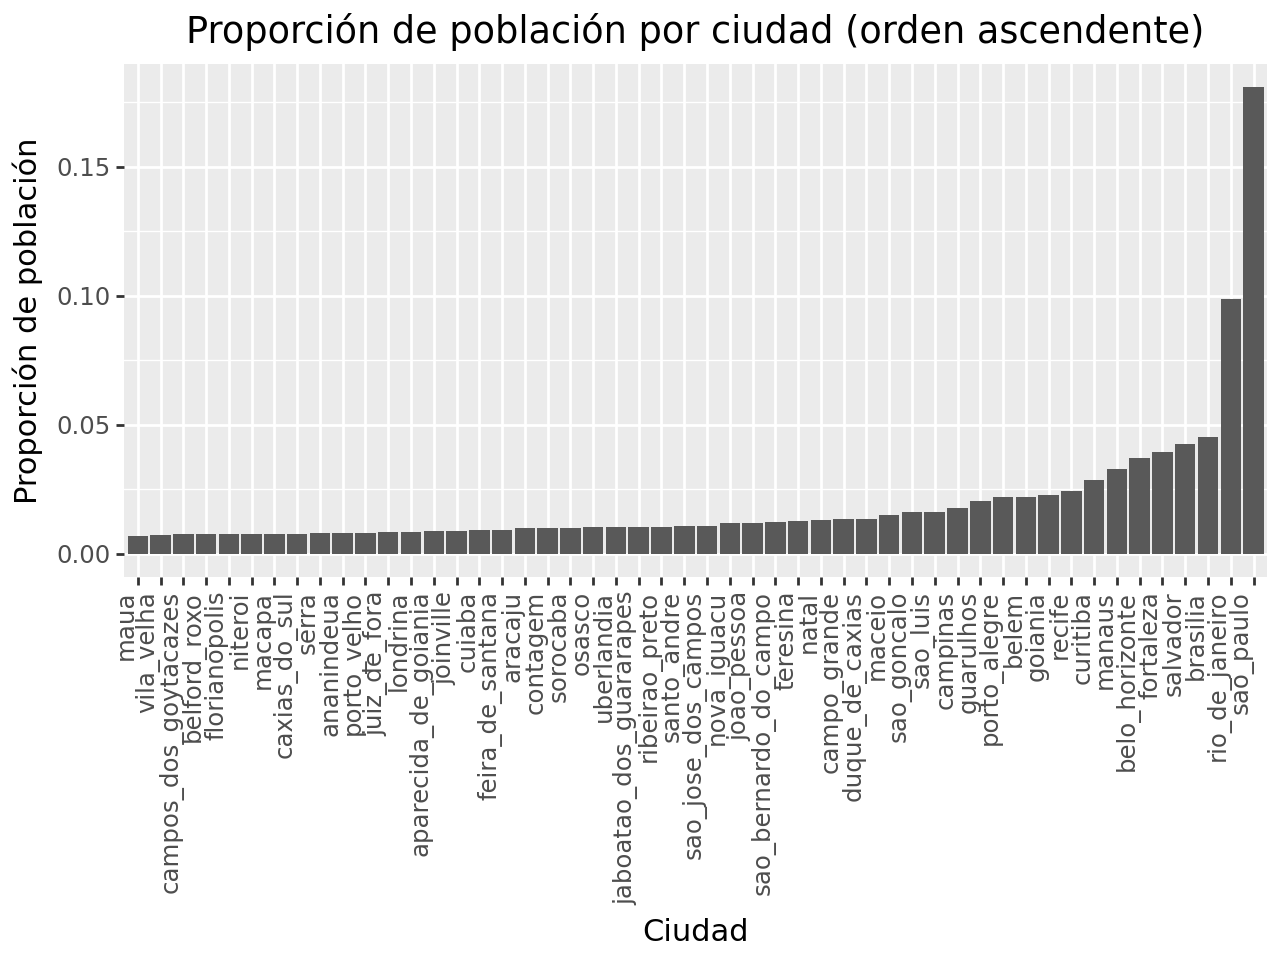

In [22]:
## ggplot de la proporción de población por ciudad


# Refactorizamos usando Polars para mantener la eficiencia y claridad en la manipulación de datos.
# Ordenamos las ciudades por su proporción de población y convertimos a pandas solo para graficar.
pop_pd = (
    pop_por_ciudad
    .sort("prop_population")
    .with_columns(
        pl.col("city").cast(pl.Categorical)
    )
)

(
    ggplot(
        pop_pd,
        aes(x="city", y="prop_population")
    )
    + geom_bar(stat="identity")
    + theme(axis_text_x=element_text(rotation=90, hjust=1))
    + labs(title="Proporción de población por ciudad (orden ascendente)", x="Ciudad", y="Proporción de población")
)

### La Fórmula Final Explicada

Para diseñar el experimento sintético perfecto, necesitamos encontrar la combinación de ciudades que mejor represente el comportamiento promedio del mercado antes de cualquier intervención. Esta ecuación es el "corazón" del diseño y busca resolver un problema de optimización cuadrática con restricciones:

$$
\min_{w, v} \| \mu_{pre} - Y_{pre} w - \alpha_0 \|^2 + \| \mu_{pre} - Y_{pre} v - \beta_0 \|^2
$$

Bajo las siguientes condiciones conceptuales:

| Término | Significado en "Lenguaje Humano" |
| :--- | :--- |
| $\min_{w, v}$ | **Búsqueda Óptima:** "Encuentra la mejor combinación de pesos para el Grupo de Tratamiento ($w$) y el Grupo de Control ($v$)." |
| $\mu_{pre} - Y_{pre} w$ | **Minimización del Error:** "Haz que la diferencia entre el promedio real del mercado ($\mu_{pre}$) y mi grupo de ciudades seleccionadas ($Y_{pre} w$) sea lo más cercana a cero posible." |
| $\alpha_0, \beta_0$ | **Ajuste de Nivel (Interceptos):** Permiten que los grupos tengan diferentes volúmenes absolutos de descargas, siempre y cuando sigan la misma **tendencia** (paralelismo). |
| $\sum w_i = 1$ | **Normalización:** "Asegúrate de que la suma de todas las participaciones de las ciudades sea exactamente el 100%." |
| $w_i v_i = 0$ | **Exclusividad Mutua:** "Si una ciudad está en el grupo de tratamiento, tiene terminantemente prohibido estar en el grupo de control." |
| $\|w\|_0 \leq m$ | **Restricción de Dispersión (Sparsity):** "No me permitas elegir más de $m$ ciudades para el tratamiento" (para mantener el experimento manejable y dentro de presupuesto). |



## Trying a Random Set of Treated Units


In [23]:
# Construimos un mapa ciudad -> peso (proporción de población)
pesos = dict(
    pop_por_ciudad.select("city", "prop_population").to_numpy()
)

# Combinación lineal: suma de (descargas_ciudad * peso_ciudad)
y_avg = df_piv.select(
    pl.sum_horizontal(
        [pl.col(c) * pesos[c] for c in df_piv.columns if c != "date"]
    ).alias("y_avg")
)

geos = list(df_piv.columns)
geos.remove("date")
n_tr = 5

In [24]:
# Seleccionar 5 ciudades random y checamos el performance de la combinación lineal

np.random.seed(1)
nad_geos = np.random.choice(geos, n_tr, replace=False)
nad_geos

array(['manaus', 'recife', 'sao_bernardo_do_campo', 'salvador', 'aracaju'],
      dtype='<U23')

In [25]:
# Usar Synthetic Control con las ciudades seleccionadas con intercepto
from sklearn.base import BaseEstimator, RegressorMixin
from sklearn.utils.validation import check_X_y, check_array, check_is_fitted
import cvxpy as cp

class SyntheticControl(BaseEstimator, RegressorMixin):

    def __init__(self, fit_intercept=False):
        self.fit_intercept = fit_intercept

    def fit(self, y_pre_co, y_pre_tr):

        y_pre_co, y_pre_tr = check_X_y(y_pre_co, y_pre_tr)
        
        # add intercept
        intercept = np.ones((y_pre_co.shape[0], 1))*self.fit_intercept
        X = np.concatenate([intercept, y_pre_co], axis=1)
        w = cp.Variable(X.shape[1])
        
        objective = cp.Minimize(cp.sum_squares(X@w - y_pre_tr))
        constraints = [cp.sum(w[1:]) == 1, w[1:] >= 0]
        
        problem = cp.Problem(objective, constraints)
        
        self.loss_ = problem.solve(verbose=False)
        self.w_ = w.value[1:] # remove intercept
        
        self.is_fitted_ = True
        return self
        
        
    def predict(self, y_co):

        check_is_fitted(self)
        y_co = check_array(y_co)
        
        return y_co @ self.w_

In [26]:
# Predecir y_avg con las 5 ciudades seleccionadas usando Synthetic Control con intercepto

def get_sc(geos, df_sc, y_mean_pre):
    geos = np.array(geos)
    model = SyntheticControl(fit_intercept=True)
    model.fit(df_sc.select(pl.col(geos)).to_numpy(), y_mean_pre.to_numpy().flatten())
    
    selected_geos = geos[np.abs(model.w_) > 1e-5]

    return {"geos": selected_geos, "loss": model.loss_}

get_sc(nad_geos, df_piv, y_avg)

{'geos': array(['salvador', 'aracaju'], dtype='<U23'),
 'loss': 1598627.13372196}

In [27]:
def ger_sc_st_combination(treatment_geos, df_sc, y_mean_pre):
    treatment_result = get_sc(treatment_geos, df_sc, y_mean_pre)

    remaining_geos = [
        c for c in df_sc.columns
        if c not in treatment_result["geos"] and c != "date"
    ]

    control_result = get_sc(remaining_geos, df_sc, y_mean_pre)

    return {
        "st_geos": treatment_result["geos"],
        "sc_geos": control_result["geos"],
        "loss": treatment_result["loss"] + control_result["loss"]
    }



resulting_geos = ger_sc_st_combination(nad_geos, df_piv, y_avg)
resulting_geos.get("st_geos")

array(['salvador', 'aracaju'], dtype='<U23')

C:\Users\sergi\AppData\Roaming\Python\Python313\site-packages\sklearn\utils\validation.py:1406: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples, ), for example using ravel().
C:\Users\sergi\AppData\Roaming\Python\Python313\site-packages\sklearn\utils\validation.py:1406: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples, ), for example using ravel().


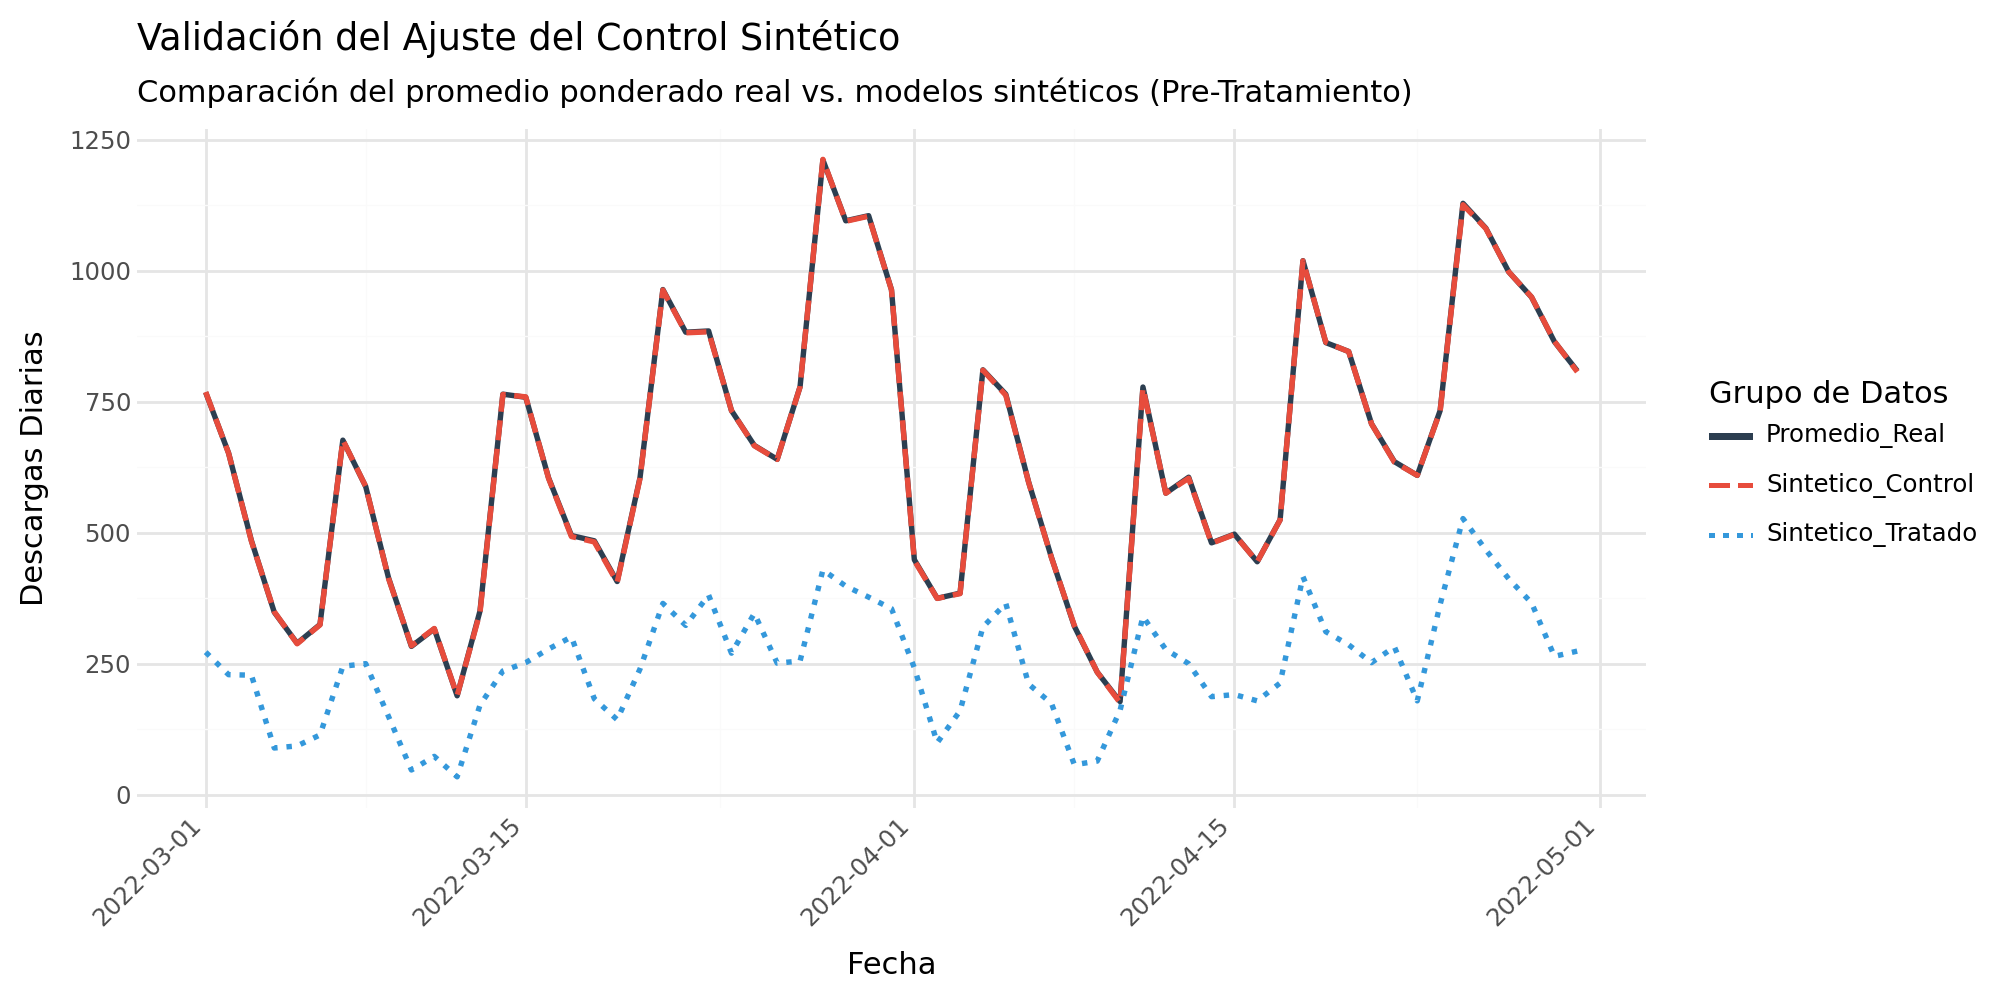

In [28]:
import matplotlib.pyplot as plt
synthetic_tr = SyntheticControl(fit_intercept=True)
synthetic_co = SyntheticControl(fit_intercept=True)

synthetic_tr.fit(df_piv[resulting_geos.get("st_geos")], y_avg)
synthetic_co.fit(df_piv[resulting_geos.get("sc_geos")], y_avg)

# 1. Construimos un DataFrame combinando las fechas, el promedio real y las predicciones
# Usamos .select() y .with_columns() de Polars para mantener la eficiencia
plot_data = df_piv.select("date").with_columns([
    y_avg.to_series().alias("Promedio_Real"),
    pl.Series("Sintetico_Control", synthetic_co.predict(df_piv.select(resulting_geos.get("sc_geos")).to_numpy())),
    pl.Series("Sintetico_Tratado", synthetic_tr.predict(df_piv.select(resulting_geos.get("st_geos")).to_numpy()))
])

# 2. Transformamos a formato "largo" (unpivot) para que ggplot pueda mapear los colores por Serie
plot_long = plot_data.unpivot(
    index="date", 
    on=["Promedio_Real", "Sintetico_Control", "Sintetico_Tratado"],
    variable_name="Serie", 
    value_name="Descargas"
)

# 3. Visualización con plotnine (ggplot)
# Buscamos verificar visualmente que las líneas se solapen casi perfectamente en el periodo pre-intervención
(
    ggplot(plot_long, aes(x="date", y="Descargas", color="Serie", linetype="Serie"))
    + geom_line(size=1.1)
    + scale_color_manual(values=["#2c3e50", "#e74c3c", "#3498db"]) # Colores elegantes: Carbón, Rojo, Azul
    + scale_linetype_manual(values=["solid", "dashed", "dotted"])
    + theme_minimal()
    + labs(
        title="Validación del Ajuste del Control Sintético",
        subtitle="Comparación del promedio ponderado real vs. modelos sintéticos (Pre-Tratamiento)",
        x="Fecha",
        y="Descargas Diarias",
        color="Grupo de Datos",
        linetype="Grupo de Datos"
    )
    + theme(
        axis_text_x=element_text(rotation=45, hjust=1),
        figure_size=(10, 5)
    )
)

## Random Search

In [29]:
from joblib import Parallel, delayed
from toolz import partial

np.random.seed(1)
geo_samples = [np.random.choice(geos, n_tr, replace=False) for _ in range(1000)]

est_combination = partial(ger_sc_st_combination, df_sc=df_piv, y_mean_pre=y_avg)
results = Parallel(n_jobs=-1)(delayed(est_combination)(goes) for goes in geo_samples)

resulting_geos = min(results, key=lambda x: x.get("loss"))
resulting_geos.get("st_geos")

array(['sao_bernardo_do_campo', 'joao_pessoa', 'feira_de_santana',
       'sao_paulo', 'porto_alegre'], dtype='<U23')

C:\Users\sergi\AppData\Local\Temp\ipykernel_40644\939371930.py:25: UserWarning: Solution may be inaccurate. Try another solver, adjusting the solver settings, or solve with verbose=True for more information.


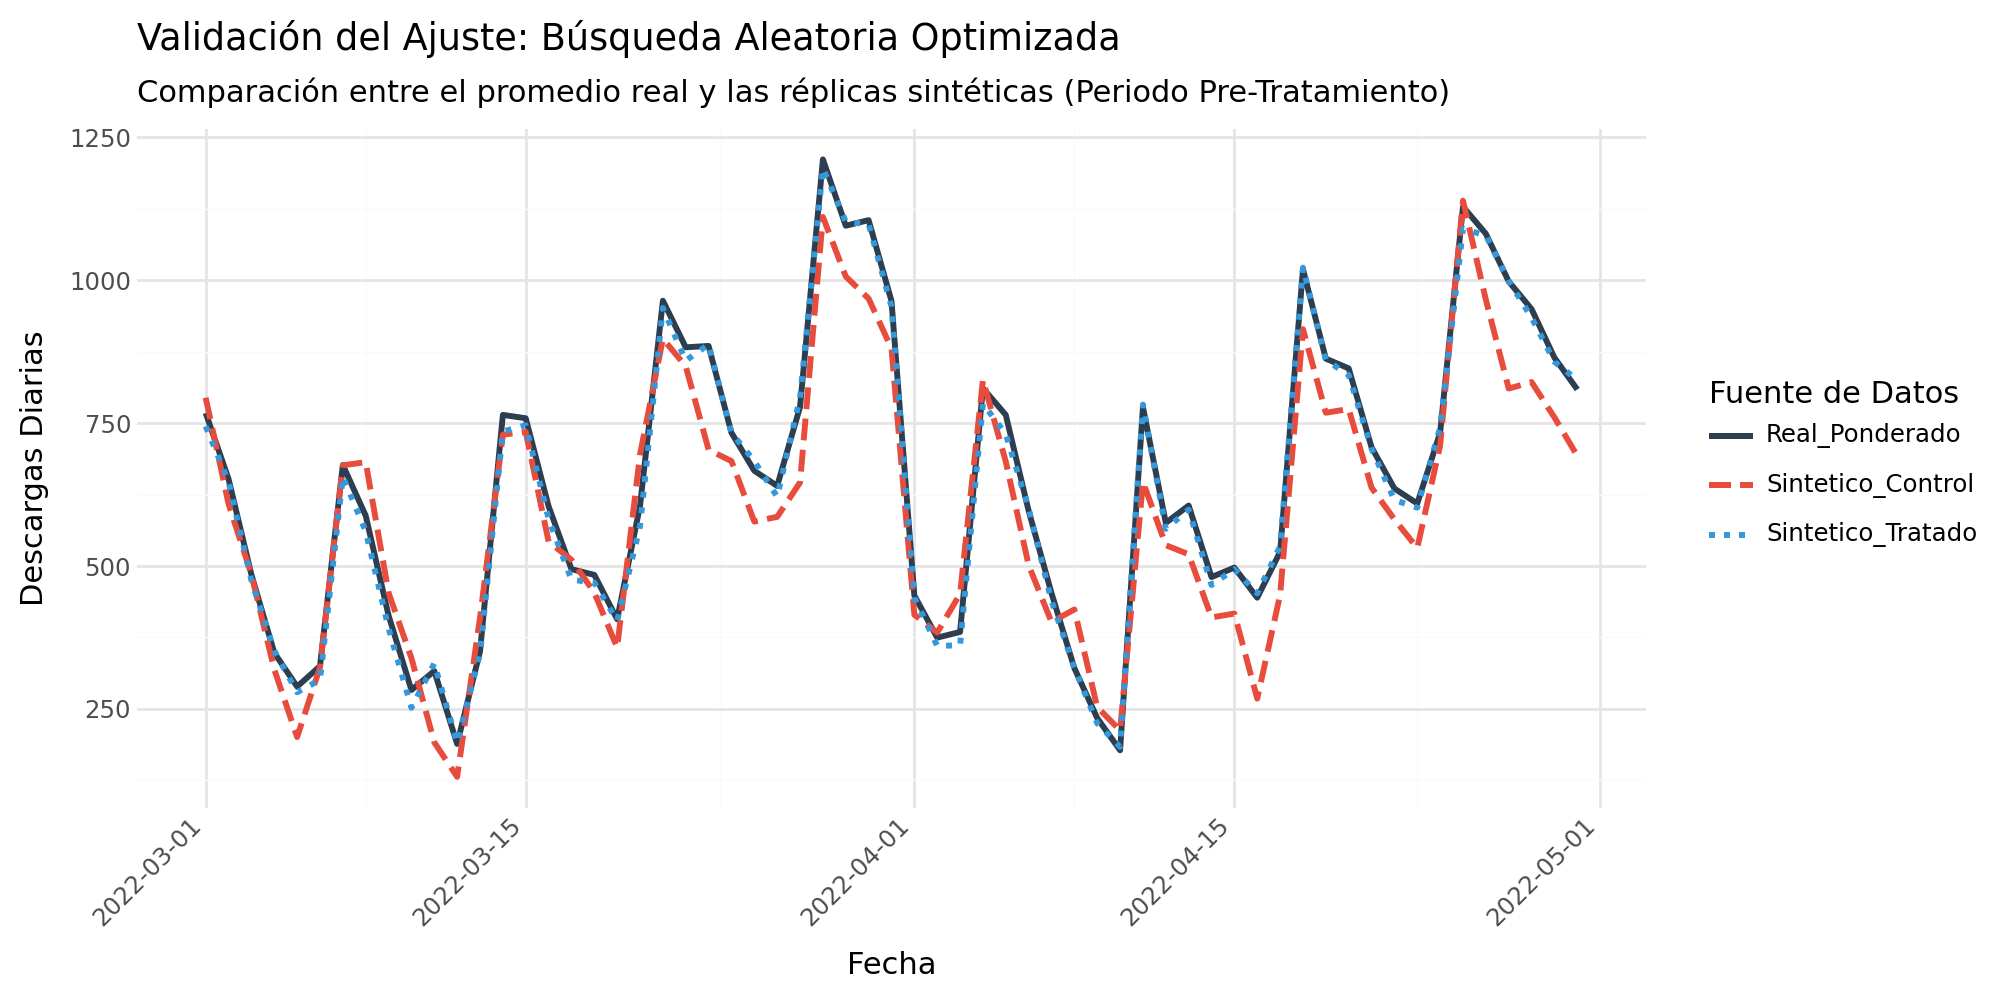

In [30]:

# Re-entrenamos los modelos con las ciudades óptimas encontradas por la búsqueda aleatoria
# (necessary because resulting_geos was updated and dimensions no longer match the previous fit)
synthetic_tr = SyntheticControl(fit_intercept=True)
synthetic_co = SyntheticControl(fit_intercept=True)

synthetic_tr.fit(df_piv.select(resulting_geos.get("st_geos")).to_numpy(), y_avg.to_numpy().flatten())
synthetic_co.fit(df_piv.select(resulting_geos.get("sc_geos")).to_numpy(), y_avg.to_numpy().flatten())

# 1. Preparación de los datos usando Polars
# Combinamos la fecha con el valor real y las predicciones de ambos modelos sintéticos
plot_data = df_piv.select("date").with_columns([
    y_avg.to_series().alias("Real_Ponderado"),
    pl.Series("Sintetico_Control", synthetic_co.predict(df_piv.select(resulting_geos.get("sc_geos")).to_numpy())),
    pl.Series("Sintetico_Tratado", synthetic_tr.predict(df_piv.select(resulting_geos.get("st_geos")).to_numpy()))
])

# 2. Transformación a formato largo (tidy data) para ggplot
plot_long = plot_data.unpivot(
    index="date",
    on=["Real_Ponderado", "Sintetico_Control", "Sintetico_Tratado"],
    variable_name="Serie",
    value_name="Descargas"
)

# 3. Visualización con plotnine
(
    ggplot(plot_long, aes(x="date", y="Descargas", color="Serie", linetype="Serie"))
    + geom_line(size=1.2)
    + scale_color_manual(values=["#2c3e50", "#e74c3c", "#3498db"])  # Colores: Oscuro (Real), Rojo (Control), Azul (Tratado)
    + scale_linetype_manual(values=["solid", "dashed", "dotted"])
    + theme_minimal()
    + labs(
        title="Validación del Ajuste: Búsqueda Aleatoria Optimizada",
        subtitle="Comparación entre el promedio real y las réplicas sintéticas (Periodo Pre-Tratamiento)",
        x="Fecha",
        y="Descargas Diarias",
        color="Fuente de Datos",
        linetype="Fuente de Datos"
    )
    + theme(
        figure_size=(10, 5),
        axis_text_x=element_text(rotation=45, hjust=1)
    )
)


## Switchback Experiment

In [31]:
df = pl.read_csv("../data/sb_exp_every.csv")
df.head()

d,delivery_time,delivery_time_1,delivery_time_0,tau
i64,f64,f64,f64,f64
1,2.84,2.84,5.84,-3.0
0,4.49,1.49,6.49,-5.0
0,7.27,2.27,8.27,-6.0
1,5.27,2.27,8.27,-6.0
1,5.59,4.59,10.59,-6.0


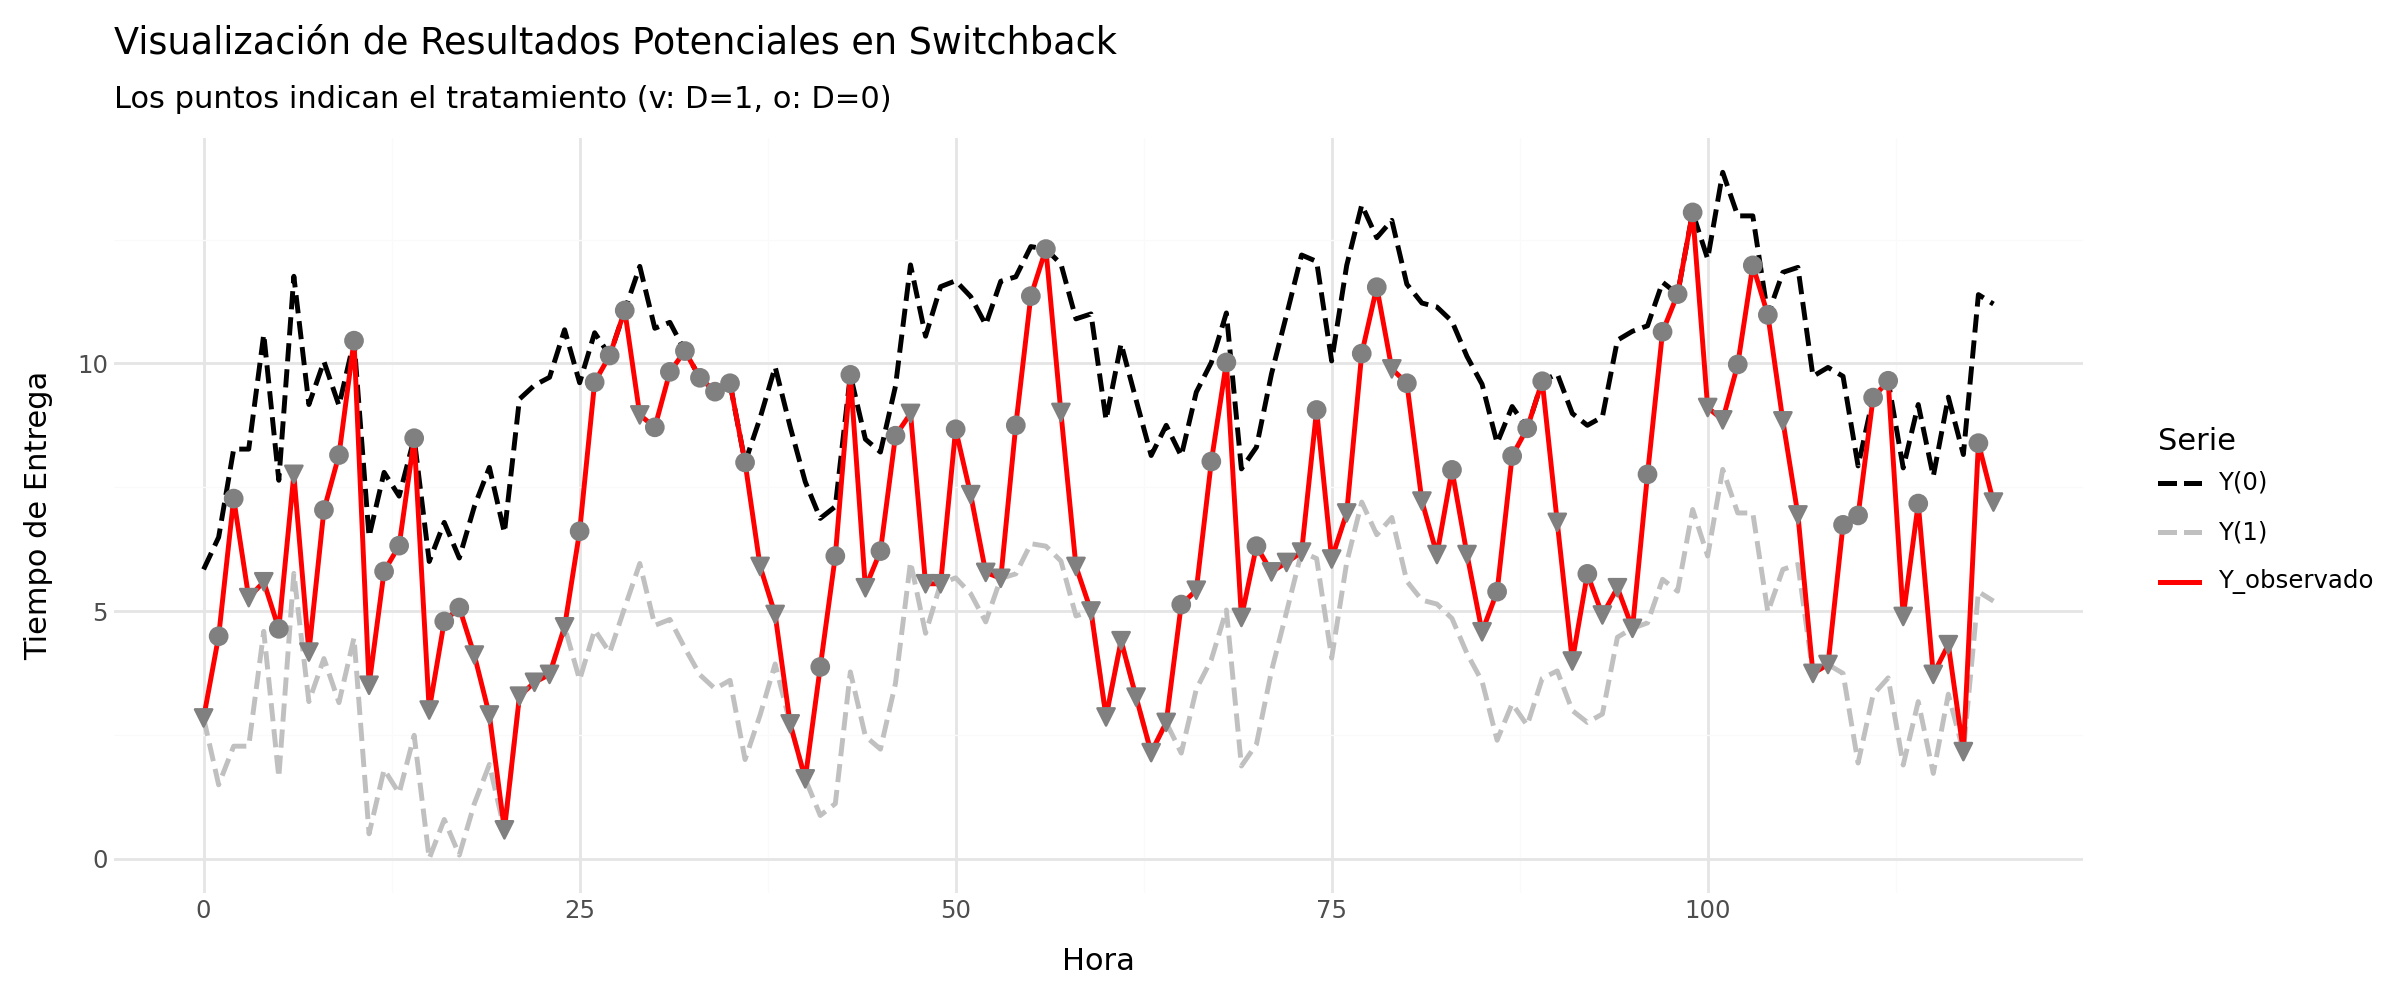

In [32]:
# Mantenemos la lógica de Polars para eficiencia
df_idx = df.with_row_index("hour")

# Transformamos a formato largo para mapear las series de resultados potenciales
lines = (
    df_idx.select(["hour", "delivery_time_0", "delivery_time_1", "delivery_time"])
    .unpivot( # Usamos el unpivot de Polars
        index="hour",
        on=["delivery_time_0", "delivery_time_1", "delivery_time"],
        variable_name="Serie",
        value_name="val",
    )
    .with_columns(
        pl.when(pl.col("Serie") == "delivery_time_0").then(pl.lit("Y(0)"))
        .when(pl.col("Serie") == "delivery_time_1").then(pl.lit("Y(1)"))
        .otherwise(pl.lit("Y_observado"))
        .alias("Serie")
    )
)

# Convertimos a pandas solo para la visualización final con plotnine
lines_pd = lines.to_pandas()
df_idx_pd = df_idx.to_pandas()

(
    ggplot(lines_pd, aes(x="hour", y="val", color="Serie", linetype="Serie"))
    + geom_line(size=1)
    + geom_point(
        data=df_idx_pd[df_idx_pd["d"] == 1],
        mapping=aes(x="hour", y="delivery_time"),
        shape="v", size=3, color="gray", inherit_aes=False 
    )
    + geom_point(
        data=df_idx_pd[df_idx_pd["d"] == 0],
        mapping=aes(x="hour", y="delivery_time"),
        shape="o", size=3, color="gray", inherit_aes=False
    )
    # Definimos colores válidos explícitamente
    + scale_color_manual(values={"Y(0)": "black", "Y(1)": "silver", "Y_observado": "red"})
    + scale_linetype_manual(values={"Y(0)": "dashed", "Y(1)": "dashed", "Y_observado": "solid"})
    + labs(
        title="Visualización de Resultados Potenciales en Switchback",
        subtitle="Los puntos indican el tratamiento (v: D=1, o: D=0)",
        x="Hora", y="Tiempo de Entrega"
    )
    + theme_minimal()
    + theme(figure_size=(12, 5))
)


## Potential Outcomes of Sequences

In [33]:
# Creamos las columnas d_l0, d_l1, ..., d_l6 usando shift en Polars
df_lags = df_idx.with_columns([
    pl.col("d").shift(l).alias(f"d_l{l}") for l in range(7)
])

# Mostramos solo las columnas de lags
df_lags.select([f"d_l{l}" for l in range(7)]).head()

d_l0,d_l1,d_l2,d_l3,d_l4,d_l5,d_l6
i64,i64,i64,i64,i64,i64,i64
1,null,null,null,null,null,null
0,1,null,null,null,null,null
0,0,1,null,null,null,null
1,0,0,1,null,null,null
1,1,0,0,1,null,null


In [34]:
import statsmodels.formula.api as smf

model = smf.ols(
    "delivery_time ~" + " + ".join([f"d_l{l}" for l in range(7)]),
    data=df_lags.to_pandas()
).fit()

model.summary().tables[1]

,coef,std err,t,P>|t|,[0.025,0.975]
Intercept,9.3270,0.461,20.246,0.000,8.414,10.240
d_l0,-2.9645,0.335,-8.843,0.000,-3.629,-2.300
d_l1,-1.8861,0.339,-5.560,0.000,-2.559,-1.213
d_l2,-1.0013,0.340,-2.943,0.004,-1.676,-0.327
d_l3,0.2594,0.341,0.762,0.448,-0.416,0.935
d_l4,0.1431,0.340,0.421,0.675,-0.531,0.817
d_l5,0.1388,0.340,0.408,0.684,-0.536,0.813
d_l6,0.5588,0.336,1.662,0.099,-0.108,1.225


In [35]:
# remember remove the intercept from the model to get the correct estimates for the lags
tau_m_hat = model.params[1:].sum()
se_tau_m_hat = np.sqrt((model.bse[1:]**2).sum())
print("tau_m_hat:", tau_m_hat)
print("95% CI:", (tau_m_hat - 1.96*se_tau_m_hat, tau_m_hat + 1.96*se_tau_m_hat))

tau_m_hat: -4.75168611527203
95% CI: (np.float64(-6.508718378154567), np.float64(-2.994653852389494))


In [36]:
tau_mean = df.select(pl.col("tau").mean()).item()
print("tau_mean:", tau_mean)

tau_mean: -5.966666666666667


In [37]:
# remember remove the intercept from the model to get the correct estimates for the lags
tau_m_hat = model.params[1:4].sum()
se_tau_m_hat = np.sqrt((model.bse[1:4]**2).sum())
print("tau_m_hat:", tau_m_hat)
print("95% CI:", (tau_m_hat - 1.96*se_tau_m_hat, tau_m_hat + 1.96*se_tau_m_hat))

tau_m_hat: -5.8518568954423
95% CI: (np.float64(-7.000105171362171), np.float64(-4.703608619522428))


## Designed-Based Estimation

In [38]:
rad_points_3 = np.array([True, False, False]*2)
rad_points_3

array([ True, False, False,  True, False, False])

In [40]:
rad_points_3.cumsum()

array([1, 1, 1, 2, 2, 2])

In [41]:
from numpy.lib.stride_tricks import sliding_window_view

m = 2

sliding_window_view(rad_points_3.cumsum(), window_shape=m+1)

array([[1, 1, 1],
       [1, 1, 2],
       [1, 2, 2],
       [2, 2, 2]])

Aqui se pueden calcular el numero de randomizaciones posibles para un experimento switchback con $T$ periodos y $N$ unidades de análisis

In [42]:
np.diff(sliding_window_view(rad_points_3.cumsum(), window_shape=m+1), axis=1)

array([[0, 0],
       [0, 1],
       [1, 0],
       [0, 0]])

In [43]:
n_rand_windows = np.concatenate([
    [np.nan]*m,
    np.diff(sliding_window_view(rad_points_3.cumsum(), window_shape=m+1), axis=1).sum(axis=1)+1
])
n_rand_windows

array([nan, nan,  1.,  2.,  2.,  1.])

In [44]:
p = 0.5
p**n_rand_windows

array([ nan,  nan, 0.5 , 0.25, 0.25, 0.5 ])

In [45]:
def compute_p(rand_points, m, p=0.5):
    n_windows_last_m = np.concatenate([
        [np.nan]*m,
        np.diff(sliding_window_view(rand_points.cumsum(), m+1),
                axis=1).sum(axis=1)+1
    ])
    return p**n_windows_last_m

compute_p(np.ones(6)==1, 2, 0.5)

array([  nan,   nan, 0.125, 0.125, 0.125, 0.125])

In [47]:
rand_points = np.array([True, False, False, True, False, True, False])
compute_p(rand_points, 2, 0.5)

array([ nan,  nan, 0.5 , 0.25, 0.25, 0.25, 0.25])

In [49]:
def last_m_d_equal(d_vec, d, m):
    return np.concatenate([
    [np.nan]*m,
    (sliding_window_view(d_vec, m+1)==d).all(axis=1)
    ])
print(last_m_d_equal([1, 1, 1, 0, 0, 0], 1, m=2))
print(last_m_d_equal([1, 1, 1, 0, 0, 0], 0, m=2))

[nan nan  1.  0.  0.  0.]
[nan nan  0.  0.  0.  1.]


In [50]:
def ipw_switchback(d, y, rand_points, m, p=0.5):
    p_last_m_equal_1 = compute_p(rand_points, m=m, p=p)
    p_last_m_equal_0 = compute_p(rand_points, m=m, p=1-p)
    last_m_is_1 = last_m_d_equal(d,1,m)
    last_m_is_0 = last_m_d_equal(d,0,m)
    y1_rec = y*last_m_is_1/p_last_m_equal_1
    y0_rec = y*last_m_is_0/p_last_m_equal_0

    return np.mean((y1_rec-y0_rec)[m:])

In [54]:
# Usamos .get_column() para obtener una Serie (1D) y evitar errores de dimensiones
ipw_switchback(
    df.get_column("d").to_numpy(),
    df.get_column("delivery_time").to_numpy(),
    np.ones(len(df)) == 1,
    m=2, p=0.5
)

np.float64(-7.426440677966101)

## Optimal switchback design

In [62]:
m = 2
T = 12
n = T/m

np.isin(
    np.arange(1, T+1),
    [1] + [i*m+1 for i in range(2, int(n)-1)]
)*1

array([1, 0, 0, 0, 1, 0, 1, 0, 1, 0, 0, 0])

In [66]:
m = 3
T = 15
n = T/m

np.isin(
    np.arange(1, T+1),
    [1] + [i*m+1 for i in range(2, int(n)-1)]
)*1

array([1, 0, 0, 0, 0, 0, 1, 0, 0, 1, 0, 0, 0, 0, 0])

## Robust Variance

In [69]:
df_opt = pl.read_csv("../data/sb_exp_opt.csv")
df_opt.head(6)

rand_points,d,delivery_time
bool,i64,f64
true,0,5.84
false,0,5.4
false,0,8.86
false,0,8.79
true,0,10.93
false,0,7.02


In [73]:
tau_hat = ipw_switchback(
    df_opt.get_column("d").to_numpy(),
    df_opt.get_column("delivery_time").to_numpy(),
    df_opt.get_column("rand_points").to_numpy(),
    m=2, p=0.5
)
print("tau_hat:", tau_hat)

tau_hat: -9.921016949152545


Una vez que hemos obtenido nuestra estimación puntual del efecto del tratamiento ($\hat{\tau}$), debemos cuantificar la incertidumbre. En los experimentos **Switchback**, las observaciones están correlacionadas en el tiempo, lo que rompe el supuesto de independencia de la estadística clásica. Para solucionar esto, aplicamos una **Varianza Robusta** específicamente diseñada para este esquema de aleatorización.

### La Fórmula de la Varianza Robusta

Para un diseño óptimo con periodos de bloque $m$, la varianza se estima como:

$$
\sigma_\tau^2 = \frac{1}{(T-m)^2} \left[ 8Y_1^2 + \sum_{k=2}^{K-1} 32Y_k^2 \cdot \mathbb{1}(d_{km+1} = d_{(k+1)m+1}) + 8Y_K^2 \right]
$$

### Desglose de Componentes

Para entender esta ecuación, podemos verla como una suma ponderada de la variabilidad en diferentes momentos del experimento:

| Componente | Expresión | Significado Pedagógico |
| :--- | :--- | :--- |
| **Factor de Escala** | $\frac{1}{(T-m)^2}$ | Normaliza el error total según el tamaño de la ventana de tiempo efectiva del experimento. |
| **Efecto de Extremos** | $8Y_1^2 + 8Y_K^2$ | El primer y último bloque de datos tienen un peso menor porque "solo tienen un vecino" con el cual compararse en la secuencia. |
| **Cuerpo Central** | $\sum 32Y_k^2 \cdot \mathbb{1}(\dots)$ | Es el núcleo de la varianza. Multiplica por 32 la variabilidad de los bloques internos ($Y_k$), pero **solo si** el tratamiento ($d$) fue el mismo en los puntos de decisión adyacentes. |
| **Función Indicadora** | $\mathbb{1}(d_{i} = d_{j})$ | Actúa como un interruptor: si hubo un cambio de tratamiento ("switch"), esa parte de la varianza se ignora para ese bloque, ya que el cambio introduce una variabilidad externa al diseño puro. |

Esta fórmula nos permite calcular intervalos de confianza válidos incluso cuando existe una fuerte dependencia temporal entre las entregas, algo que una desviación estándar común ignoraría por completo.

---


In [74]:
np.vstack(np.hsplit(np.array([1,1,1,2,2,3]), 3))

array([[1, 1],
       [1, 2],
       [2, 3]])

### ¿Qué hace la expresión?

`np.diff(np.vstack(np.hsplit(np.array([1,1,0,0,0,0]), 3))[:, 0]) == 0`

- **Divide el vector** `[1,1,0,0,0,0]` en 3 bloques: `[1,1]`, `[0,0]`, `[0,0]`.
- **Apila los bloques** como filas de una matriz.
- **Toma el primer valor** de cada bloque: `[1, 0, 0]`.
- **Calcula la diferencia** entre estos valores consecutivos: `[-1, 0]`.
- **Compara si la diferencia es cero**: `[False, True]`.

**¿Para qué sirve?**

Detecta si el tratamiento se mantuvo igual entre bloques consecutivos:
- `True`: el tratamiento no cambió.
- `False`: hubo un cambio (switch).

Esto es clave para calcular la varianza robusta en experimentos switchback, porque solo los bloques sin cambio de tratamiento contribuyen a la varianza central.

---


In [75]:
np.diff(np.vstack(np.hsplit(np.array([1,1,0,0,0,0]), 3))[:, 0]) == 0

array([False,  True])

In [79]:
def var_opt_design(d_opt, y_opt, T, m):
    
    assert ((T//m == T/m)
            & (T//m >= 4)), "T must be divisible by m and T/m >= 4"
    
    # discard 1st block
    y_m_blocks = np.vstack(np.hsplit(y_opt, int(T/m))).sum(axis=1)[1:]
    
    # take 1st column
    d_m_blocks = np.vstack(np.split(d_opt, int(T/m))[1:])[:, 0] 
    
    return (
        8*y_m_blocks[0]**2 
        + (32*y_m_blocks[1:-1]**2*(np.diff(d_m_blocks)==0)[:-1]).sum()
        + 8*y_m_blocks[-1]**2 
    ) / (T-m)**2

In [80]:
se_hat = np.sqrt(var_opt_design(
    df_opt.get_column("d").to_numpy(),
    df_opt.get_column("delivery_time").to_numpy(),
    T=120, m=2
))
[tau_hat - 1.96*se_hat, tau_hat + 1.96*se_hat]

[np.float64(-18.490627362048095), np.float64(-1.351406536256997)]

# Resumen: Diseños Experimentales Alternativos

## 1. Control Sintético (Synthetic Control Design)

**Concepto:**
Buscar un grupo pequeño de unidades que, al combinarse y ponderarse matemáticamente, logren aproximar el comportamiento promedio de todas las unidades.

**Matemática:**
Minimiza el error entre el promedio real y los pesos asignados a las unidades de tratamiento ($w$) y de control ($v$):

$$
\min_{w,v} \|\bar{Y}_{pre} - Y_{pre}w - \alpha_0\|^2 + \|\bar{Y}_{pre} - Y_{pre}v - \beta_0\|^2
$$

**Restricciones:**
- Los pesos deben sumar 1
- Deben ser positivos
- Una unidad no puede ser control y tratamiento al mismo tiempo ($w_i v_i = 0$)
- Se limita la cantidad de unidades de tratamiento

**¿Cuándo usarlo?**
Ideal cuando tienes pocas unidades experimentales y el efecto carryover es muy grande (el efecto del tratamiento tarda mucho en disiparse).

---

## 2. Experimentos Switchback (Switchback Experiments)

**Concepto:**
Cuando tienes muy pocas unidades (incluso una sola), alternas el tratamiento (lo enciendes y lo apagas) sobre esa misma unidad a lo largo del tiempo, realizando múltiples comparaciones de "antes y después".

**¿Cuándo usarlo?**
La mejor alternativa cuando el efecto carryover es pequeño.

**Reglas para el Diseño Óptimo:**

- **Probabilidad:** Para maximizar el poder estadístico, la probabilidad de recibir el tratamiento debe ser 50%.

- **Con Arrastre/Carryover ($m > 0$):**
  - Aleatoriza cada $m+1$ periodos.
  - Los puntos óptimos de aleatorización ($t^*$) son:
    $$
    t^* = 1, 2m+1, 3m+1, \dots, (n-2)m+1
    $$
  - Nota: $T$ debe ser divisible por $m$ y debe haber al menos 4 bloques ($n = T/m \ge 4$).

---